In [12]:
import numpy as np
import matplotlib.pylab as plt
import numpy as np, time, astropy.io.fits, os, sys
import pymaster as nmt
import sacc
import healpy as hp  
import pyccl as ccl


# Relevant functions:

In [19]:
def GetGalMask(nside, lat=None, fsky=None, nest=False):
	"""
	Returns a symmetric Galactic Mask in Healpix format at nside resolution.
	Pixels with latitude < |lat| deg are set to 0.
	Otherwise you input the fsky and evaluates the required latitude.
	Parameters
	----------
	nside : int
		Resolution of the Healpix pixelization scheme
	lat : float
		Latitude of the galatic cut
	fsky : float
		Sky coverage of the footprint
	nest : bool [def=False]
		If True, nested pixelation scheme is considered for the output pixels
	"""
	if lat is None:
		if fsky is not None:
			lat = np.rad2deg(np.arcsin(1. - fsky))
		else:
			raise ValueError("Missing lat or fsky !")

	mask = np.zeros(hp.nside2npix(nside))
	theta_cut = np.deg2rad(90. - lat)
	mask[np.where((hp.pix2ang(nside, np.arange(mask.size), nest=nest))[0] >= (np.pi - theta_cut))] = 1.
	mask[np.where((hp.pix2ang(nside, np.arange(mask.size), nest=nest))[0] <= theta_cut)] = 1.

	return mask


def bin_ps(cl_in, wsp):
    """
    Returns a binned power spectrum based on the mask property as given by the coupling matrix wsp. 
    Parameters
    ----------
    wsp : Namaster coupling matrix object
         
    cl_in: Power spectrum
    """
    
    cl_bin = []
    for z in range(np.shape(cl_in)[1]):
        cl_z_all = []
        for i in range(len(cl_in)):
            Cl_th_binned = wsp.decouple_cell(wsp.couple_cell([cl_in[i,z,:][:wsp.wsp.lmax + 1]]))[0]
            cl_z_all.append(Cl_th_binned)
        cl_bin.append(cl_z_all)
        
    return np.array(cl_bin)





def make_sacc_file( zzs,pdfs_lens,pdfs_source, binner,clgg_all, clkk_all, wins, ells,clkg_all,clkcmbk_all,cov_all, filename):
    '''
    Save in sacc format a dictionary with  all necessary inputs
    '''
    s = sacc.Sacc()
    # GC-z1
    ells = binner.get_effective_ells()
    
    # Galaxy Clustering-z1
    s.add_tracer('NZ', 'gc__0',  # Name
             quantity='galaxy_density',  # Quantity
             spin=0,  # Spin
             z=zzs[0],  # z
             nz= pdfs_lens[0])  # nz
    # GC-z2
    s.add_tracer('NZ', 'gc__1',  # Name
             quantity='galaxy_density',  # Quantity
             spin=0,  # Spin
             z=zzs[1],  # z
             nz= pdfs_lens[1])  # nz
    
    # GC-z3
    s.add_tracer('NZ', 'gc__2',  # Name
             quantity='galaxy_density',  # Quantity
             spin=0,  # Spin
             z=zzs[2],  # z
             nz= pdfs_lens[2])  # nz
    
    # GC-z4
    s.add_tracer('NZ', 'gc__3',  # Name
             quantity='galaxy_density',  # Quantity
             spin=0,  # Spin
             z=zzs[3],  # z
             nz= pdfs_lens[3])  # nz
    
    # GC-z5
    s.add_tracer('NZ', 'gc__4',  # Name
             quantity='galaxy_density',  # Quantity
             spin=0,  # Spin
             z=zzs[4],  # z
             nz= pdfs_lens[4])  # nz
    
    
    
    # Galaxy lensing-z1
    s.add_tracer('NZ', 'source__0',  # Name
             quantity='galaxy_shear',  # Quantity
             spin=0,  # Spin
             z=zzs[0],  # z
             nz= pdfs_source[0])  # nz
    
    s.add_tracer('NZ', 'source__1',  # Name
             quantity='galaxy_shear',  # Quantity
             spin=0,  # Spin
             z=zzs[1],  # z
             nz= pdfs_source[1])  # nz
    
    s.add_tracer('NZ', 'source__2',  # Name
             quantity='galaxy_shear',  # Quantity
             spin=0,  # Spin
             z=zzs[2],  # z
             nz= pdfs_source[2])  # nz
    
    s.add_tracer('NZ', 'source__3',  # Name
             quantity='galaxy_shear',  # Quantity
             spin=0,  # Spin
             z=zzs[3],  # z
             nz= pdfs_source[3])  # nz
    
    s.add_tracer('NZ', 'source__4',  # Name
             quantity='galaxy_shear',  # Quantity
             spin=0,  # Spin
             z=zzs[4],  # z
             nz= pdfs_source[4])  # nz
    # # CMBK
    
    s.add_tracer('misc', 'Kappacv',  # Name
             quantity='cmb_convergence',  # Quantity
             spin=0, ell= np.arange(3*1024)  # Spin
              )  
    ###########################################
    print(np.shape(clgg_all[0]), wins)
    s.add_ell_cl('cl_00',  # Data type
         'gc__0',  # 1st tracer's name
         'gc__0',  # 2nd tracer's name
         ells,  # Effective multipole
         clgg_all[0],  # Power spectrum values
         window=wins,  # Bandpower windows
        )
    
    s.add_ell_cl('cl_00',  # Data type
             'gc__1',  # 1st tracer's name
             'gc__1',  # 2nd tracer's name
             ells,  # Effective multipole
             clgg_all[1],  # Power spectrum values
             window=wins,  # Bandpower windows
            )
    
    
    s.add_ell_cl('cl_00',  # Data type
             'gc__2',  # 1st tracer's name
             'gc__2',  # 2nd tracer's name
             ells,  # Effective multipole
             clgg_all[2],  # Power spectrum values
             window=wins,  # Bandpower windows
            )
    
    s.add_ell_cl('cl_00',  # Data type
             'gc__3',  # 1st tracer's name
             'gc__3',  # 2nd tracer's name
             ells,  # Effective multipole
             clgg_all[3],  # Power spectrum values
             window=wins,  # Bandpower windows
            )
    
    
    s.add_ell_cl('cl_00',  # Data type
             'gc__4',  # 1st tracer's name
             'gc__4',  # 2nd tracer's name
             ells,  # Effective multipole
             clgg_all[4],  # Power spectrum values
             window=wins,  # Bandpower windows
            )
    
    s.add_ell_cl('cl_00',  # Data type
             'source__0',  # 1st tracer's name
             'source__0',  # 2nd tracer's name
             ells,  # Effective multipole
             clkk_all[0],  # Power spectrum values
             window=wins,  # Bandpower windows
            )
    
    s.add_ell_cl('cl_00',  # Data type
             'source__1',  # 1st tracer's name
             'source__1',  # 2nd tracer's name
             ells,  # Effective multipole
             clkk_all[1],  # Power spectrum values
             window=wins,  # Bandpower windows
            )
    
    s.add_ell_cl('cl_00',  # Data type
             'source__2',  # 1st tracer's name
             'source__2',  # 2nd tracer's name
             ells,  # Effective multipole
             clkk_all[2],  # Power spectrum values
             window=wins,  # Bandpower windows
            )
    s.add_ell_cl('cl_00',  # Data type
             'source__3',  # 1st tracer's name
             'source__3',  # 2nd tracer's name
             ells,  # Effective multipole
             clkk_all[3],  # Power spectrum values
             window=wins,  # Bandpower windows
            )
    s.add_ell_cl('cl_00',  # Data type
             'source__4',  # 1st tracer's name
             'source__4',  # 2nd tracer's name
             ells,  # Effective multipole
             clkk_all[4],  # Power spectrum values
             window=wins,  # Bandpower windows
            )
    
    
    
    # # Add cross with CMB power spectrum
    s.add_ell_cl('cl_00', 'gc__0', 'Kappacv', ells, clkg_all[0], window= wins)
    s.add_ell_cl('cl_00', 'gc__1', 'Kappacv', ells, clkg_all[1], window= wins)
    s.add_ell_cl('cl_00', 'gc__2', 'Kappacv', ells, clkg_all[2], window= wins)
    s.add_ell_cl('cl_00', 'gc__3', 'Kappacv', ells, clkg_all[3], window= wins)
    s.add_ell_cl('cl_00', 'gc__4', 'Kappacv', ells, clkg_all[4], window= wins)
    
    
    s.add_ell_cl('cl_00', 'source__0', 'Kappacv', ells, clkcmbk_all[0], window= wins)
    s.add_ell_cl('cl_00', 'source__1', 'Kappacv', ells, clkcmbk_all[1], window= wins)
    s.add_ell_cl('cl_00', 'source__2', 'Kappacv', ells, clkcmbk_all[2], window= wins)
    s.add_ell_cl('cl_00', 'source__3', 'Kappacv', ells, clkcmbk_all[3], window= wins)
    s.add_ell_cl('cl_00', 'source__4', 'Kappacv', ells, clkcmbk_all[4], window= wins)
    
    
    
    
    s.add_covariance(cov_all)
    s.save_fits(filename, overwrite=True)
    return

    

# Read dndz

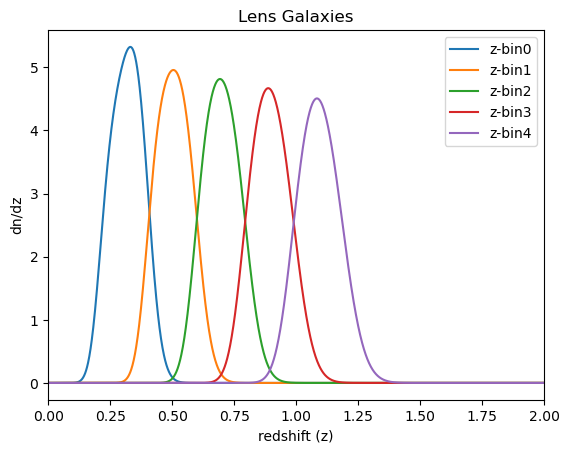

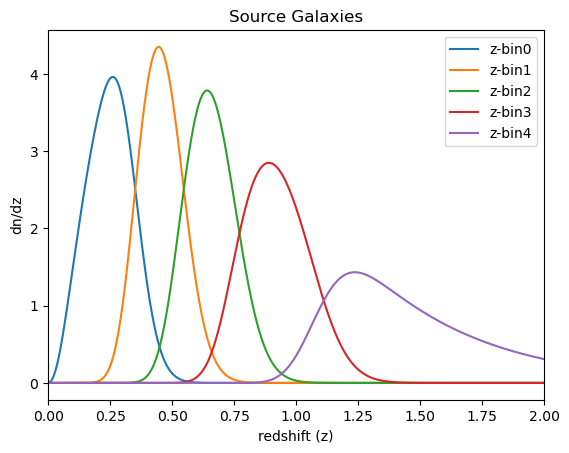

In [20]:
pz_path = '/home/s1/ggibbins/practice/lsst_like_dndz/' #where you saved the files from google drive

nside = 1024
ell = np.arange(0,  3*nside+1)

tracers_dndz = []
for i in range(5):
    zz, nz = np.load(pz_path+'NZ_lensgalaxies_bin_'+str(i)+'.npy')
    
    tracers_dndz.append(nz)
     
    plt.plot(zz,nz, label='z-bin'+str(i))
plt.ylabel('dn/dz')
plt.xlabel('redshift (z)')
plt.title('Lens Galaxies')
plt.legend()
plt.xlim(0, 2.0)

tracers_dndz = np.array(tracers_dndz)




plt.figure()
source_dndz = []
zzs= []
for i in range(5):
    zz, nz = np.load(pz_path+'NZ_sourcegalaxies_bin_'+str(i)+'.npy')
    zzs.append(zz)
    source_dndz.append(nz)
     
    plt.plot(zz,nz, label='z-bin'+str(i))
plt.ylabel('dn/dz')
plt.title('Source Galaxies')
plt.xlabel('redshift (z)')
plt.legend()
plt.xlim(0, 2.0)

source_dndz = np.array(source_dndz)

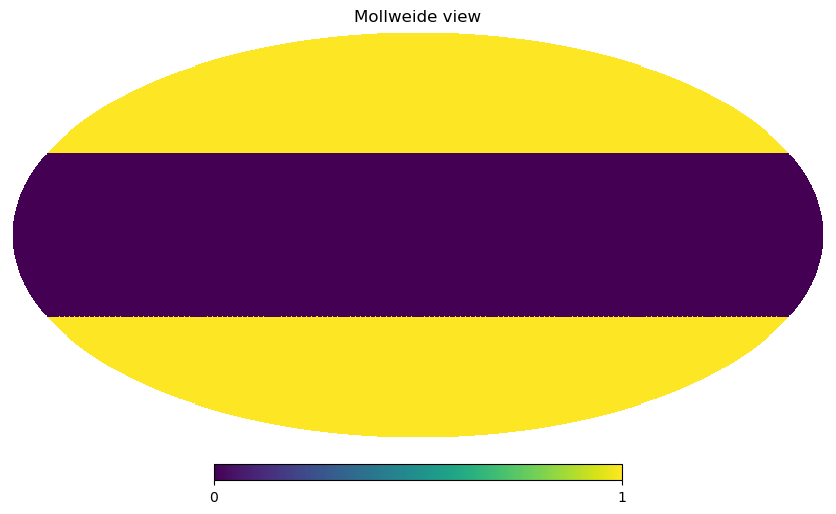

In [21]:



mask = GetGalMask(1024, lat=None, fsky= 0.5)
hp.mollview(mask)

In [22]:

nside = 1024
binner = nmt.NmtBin.from_nside_linear(nside, nlb=  30)
ell_b = binner.get_effective_ells()

f0  = nmt.NmtField(mask, [mask])
wsp = nmt.NmtWorkspace()
wsp.compute_coupling_matrix(f0 , f0 , binner)  


n_ell_large = 3*1024
n_ell = 102 
d_ell = 30
ells_large = np.arange(n_ell_large)

wins = wsp.get_bandpower_windows()
wins = (wins[0,:,0])
wins = sacc.BandpowerWindow(ells_large, wins.T)
 

In [28]:
pp='/home/s1/ggibbins/varyparams/noiseps/'

gg_all = np.load(pp+'gal_noisy_allz.npy')
kk_all = np.load(pp+'wl_noisy_allz.npy')
kcmb_k_all = np.load(pp+'wlcmb_noisy_allz.npy')
kcmbg_all = np.load(pp+'gcmb_noisy_allz.npy')

In [24]:
print(gg_all.shape)
#print(kk_all.shape)
#print(kcmb_k_all.shape)
#print(kcmbg_all.shape)

(5, 2000, 3072)


# Bin the power spectrum to turn it more stable

In [29]:
#for ps in range(2000):
clgg_bin = bin_ps(gg_all,wsp)
clkk_bin = bin_ps(kk_all,wsp)
clkg_bin = bin_ps(kcmbg_all,wsp)
clkcmbk_bin = bin_ps(kcmb_k_all,wsp)
print(clgg_bin.shape)


(2000, 5, 102)


In [27]:
print(ell_b)

[  16.5   46.5   76.5  106.5  136.5  166.5  196.5  226.5  256.5  286.5
  316.5  346.5  376.5  406.5  436.5  466.5  496.5  526.5  556.5  586.5
  616.5  646.5  676.5  706.5  736.5  766.5  796.5  826.5  856.5  886.5
  916.5  946.5  976.5 1006.5 1036.5 1066.5 1096.5 1126.5 1156.5 1186.5
 1216.5 1246.5 1276.5 1306.5 1336.5 1366.5 1396.5 1426.5 1456.5 1486.5
 1516.5 1546.5 1576.5 1606.5 1636.5 1666.5 1696.5 1726.5 1756.5 1786.5
 1816.5 1846.5 1876.5 1906.5 1936.5 1966.5 1996.5 2026.5 2056.5 2086.5
 2116.5 2146.5 2176.5 2206.5 2236.5 2266.5 2296.5 2326.5 2356.5 2386.5
 2416.5 2446.5 2476.5 2506.5 2536.5 2566.5 2596.5 2626.5 2656.5 2686.5
 2716.5 2746.5 2776.5 2806.5 2836.5 2866.5 2896.5 2926.5 2956.5 2986.5
 3016.5 3046.5]


In [ ]:
###CHANGED CODE FROM NEXT CELL ---> CHECK EQUIVALENCE
'''
for z in range(5): #why arent there 1,020,000 (2000*5*102) but instad 204,000 (2000*102) which implies they only have one redshift bin
    clgg_total = np.hstack((clgg_bin[:,z,:]).tolist())
    clkk_total = np.hstack((clkk_bin[:,z,:]).tolist())
    clkg_total = np.hstack((clkg_bin[:,z,:]).tolist())
    clkcmbk_total = np.hstack((clkcmbk_bin[:,z,:]).tolist())

print(clgg_total.shape)
print(clkk_total.shape)
print(clkg_total.shape)
print(clkcmbk_total.shape)
'''

In [46]:
np.shape(clgg_bin)

(2000, 5, 102)

In [60]:
#gabrielas og code for what i have above --> originally syntax of commented out lines except z in first but not how my np arrays are set up

clgg_total = np.hstack([clgg_bin[:,z,:] for z in range(5)])
clkk_total = np.hstack([clkk_bin[:,z,:] for z in range(5)])
clkg_total = np.hstack([clkg_bin[:,z,:] for z in range(5)])
clkcmbk_total = np.hstack([clkcmbk_bin[:,z,:] for z in range(5)])

print(np.shape(clgg_total), np.shape(clkcmbk_total))


(2000, 510) (2000, 510)


# Compute full covariance matrix and scale for the right fsky LSST will cover:

(2000, 2040)
(2040, 2040)
(2040, 2000)


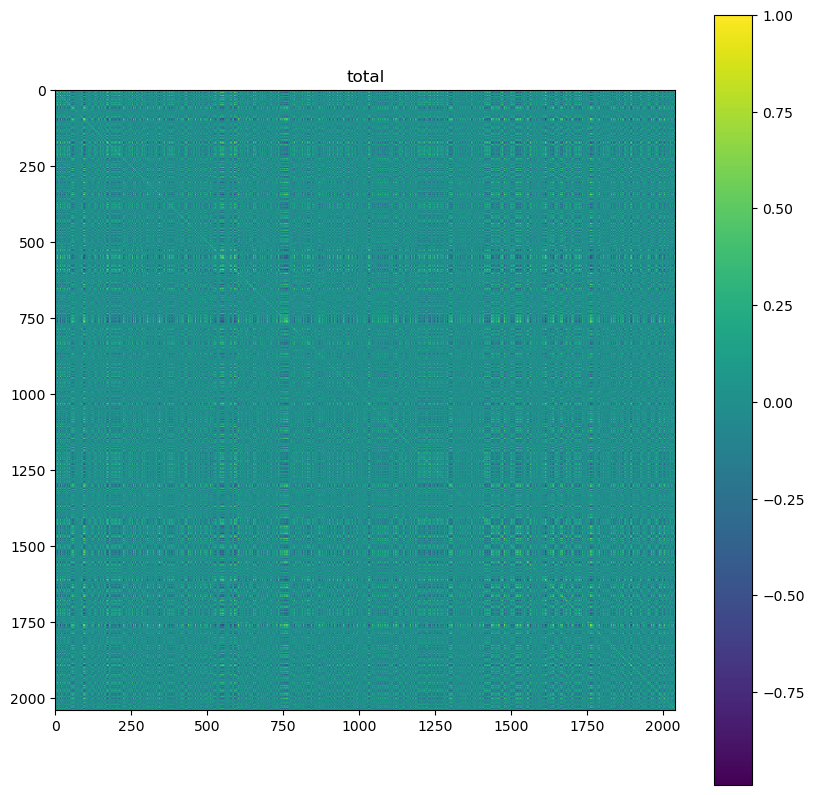

In [61]:
cls_all  = np.hstack((clgg_total,clkk_total,clkg_total,clkcmbk_total))
ratio = (41253/15000)

print(cls_all.shape)

#fix this somehow bc cov mtx needs to b square (and symmetric right so why are we finding the transpose)
cov_all = np.cov(cls_all.T)*ratio
print(cov_all.shape)
print(cls_all.T.shape)

plt.figure(figsize=(10,10))
plt.imshow(np.corrcoef(cov_all))
plt.title('total')
plt.colorbar()


In [62]:
print(cls_all.shape)

(2000, 2040)


# Read the files to setup out 'data' (in our case , this will be a theoretical Cls based on fiducial cosmology)



In [64]:
clkcmbg_all_data = []
clkcmbk_all_data = []
clgg_all_data = []
clkk_all_data = []

####Set path to Cl's from noisyps_check ---> 1d array of mean ps

for ii in range(5):
    cl_gkcmb_th = np.load('/home/s1/ggibbins/varyparams/noiseps/avgnoiseps/gcmbnoisy_z'+str(ii)+'_avg.npy')
    clkcmbg_all_data.append(wsp.decouple_cell(wsp.couple_cell([cl_gkcmb_th[:wsp.wsp.lmax + 1]]))[0])
         
    cl_kkcmb_th = np.load('/home/s1/ggibbins/varyparams/noiseps/avgnoiseps/wlcmbnoisy_z'+str(ii)+'_avg.npy')
    clkcmbk_all_data.append(wsp.decouple_cell(wsp.couple_cell([cl_kkcmb_th [:wsp.wsp.lmax + 1]]))[0])
    
    cl_gg_th = np.load('/home/s1/ggibbins/varyparams/noiseps/avgnoiseps/galnoisy_z'+str(ii)+'_avg.npy')
    clgg_all_data.append(wsp.decouple_cell(wsp.couple_cell([cl_gg_th[:wsp.wsp.lmax + 1]]))[0])
 
    cl_kk_th = np.load('/home/s1/ggibbins/varyparams/noiseps/avgnoiseps/wlnoisy_z'+str(ii)+'_avg.npy')
    clkk_all_data.append(wsp.decouple_cell(wsp.couple_cell([cl_kk_th[:wsp.wsp.lmax + 1]]))[0])


clkcmbg_all_data = np.array(clkcmbg_all_data)
clkcmbk_all_data=  np.array(clkcmbk_all_data)
clgg_all_data = np.array(clgg_all_data)
clkk_all_data= np.array(clkk_all_data)

In [66]:
pp = '/home/s1/ggibbins/varyparams/'
make_sacc_file(zzs,tracers_dndz,source_dndz, binner, clgg_all_data, clkk_all_data, wins, ell_b, clkcmbg_all_data, clkcmbk_all_data,cov_all, pp+'sacc_fiducial_xCMB.fits')
 

(102,) <sacc.windows.BandpowerWindow object at 0x7f4b22ede830>
